In [3]:
import dpluspy
import pandas 
import numpy as np
from collections import defaultdict

In [4]:
param_file = "basal_eurasian_model_params.yaml"
param_dict = defaultdict(list)
for rep in range(30):
    file = f"fitted_models/basal_eurasian_model_fit_{rep}.yaml"
    pnames, pvals = dpluspy.inference._load_params(file, param_file)
    for pname, pval in zip(pnames, pvals):
        param_dict[pname].append(pval)
tbl = pandas.DataFrame(param_dict)

In [5]:
print(tbl.to_string())

            T_NMH         T_MH_N         T_OOA         T_Stu   T_L_S         N_Anc        N_Vin          N_MH         N_Yor        N_OOA        N_Stu    N_Ust        N_Los    p_MH_N   p_N_OOA     p_L_S          m_SY      m_LY          m_LS
0   798383.145412  172716.028814  62412.028813  60828.471422  7000.0  15757.172552  2162.486783  33238.750722   9384.542906   100.000000  5792.371079  10000.0  1153.637062  0.073927  0.034592  0.327283  1.000000e-08  0.000131  1.000000e-08
1   803502.116752  197993.541794  66793.417107  62475.799947  7000.0  15752.304533  2198.580722  33713.931610   9243.122098   259.325283  5641.604018  10000.0  1160.176901  0.092357  0.035861  0.340825  1.000000e-08  0.000137  1.000000e-08
2   793445.767644  168892.313372  64847.795225  62291.051721  7000.0  15812.632023  2175.268352  33729.978409   9121.658262   155.966310  5641.163180  10000.0  1155.658826  0.070661  0.035613  0.339345  1.000000e-08  0.000137  1.000000e-08
3   801039.417131  174610.211717  67305.

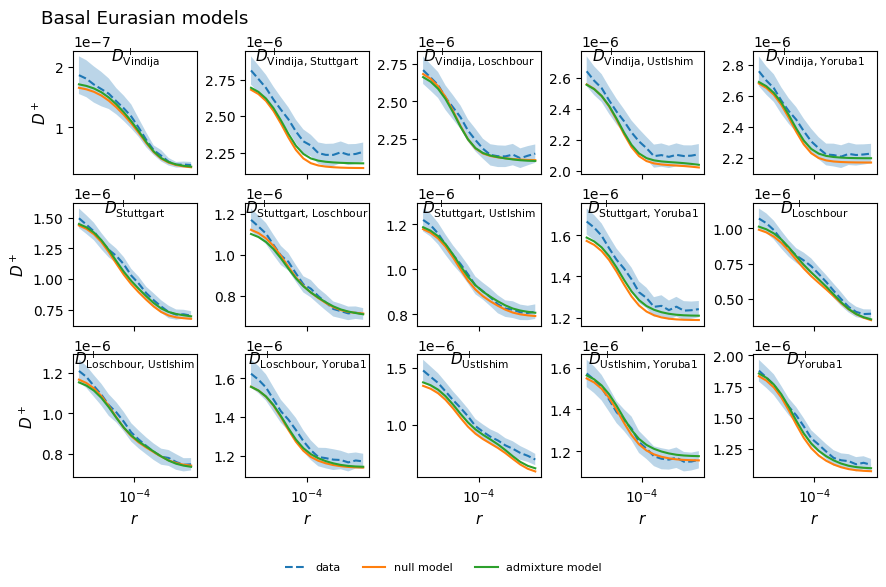

In [9]:
model_file = "edited_models/basal_eurasian_model_fit.yaml"
model_file0 = "fitted_models/basal_eurasian_null_model_fit_18.yaml"
data_file = "../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
u = 1.3e-8

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=model_file, return_dict=True)
model = dpluspy.inference.compute_bin_stats(model_file, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model0 = dpluspy.inference.compute_bin_stats(model_file0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

dpluspy.plotting.plot_D_plus_curves(
    models=[model0, model],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    title="Basal Eurasian models",
    out="figures/best_fit_models.pdf",
    labels=["data", "null model", "admixture model"],
    ax_size=1.75
)